# Syllogistic Logic CSD Sampling Experiment

**Critical Slowing Down (CSD) indicators computed from LLM response distributions across difficulty levels of syllogistic logic tasks.**

This notebook demonstrates the analysis pipeline from the CSD sampling experiment on a 280-problem syllogistic deductive logic dataset. For each of 3 LLMs (ministral-3b, ministral-8b, deepseek-v3.2), the experiment generated multiple responses at each of 14 difficulty levels (premise count 2-15), evaluated TRUE/FALSE accuracy, computed sentence embeddings, and derived a full CSD indicator battery including:
- **Embedding variance** (trace of covariance matrix)
- **Hartigan's Dip Test** (unimodality test on PC1)
- **Silhouette score** (k=2 clustering quality)
- **Bimodality coefficient**
- **Disagreement rate** (answer-level self-consistency)
- **Chain autocorrelation** (within-reasoning confidence trends)

We load pre-computed experiment results and re-run the analysis pipeline to demonstrate the methodology.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# sentence-transformers, diptest — NOT on Colab, always install
_pip('sentence-transformers==3.3.1')
_pip('diptest==0.8.0')

# numpy, scipy, scikit-learn, matplotlib, pandas — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1',
         'matplotlib==3.10.0')
    # scipy 1.16.3 requires Python 3.12+; use latest compatible version locally
    _pip('scipy>=1.13.0,<2')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import re
import sys
import time
from collections import Counter, defaultdict
from typing import Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 6)

## Data Loading

Load the pre-computed experiment results from the mini demo dataset. The data contains LLM responses to syllogistic logic problems at various difficulty levels, along with pre-computed CSD indicators.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/experiment_iter2_syllogistic_log/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"Loaded {len(examples)} examples")
print(f"Models: {sorted(set(e['metadata_model'] for e in examples))}")
print(f"Difficulty levels: {sorted(set(e['metadata_difficulty'] for e in examples))}")
print(f"\nSample example keys: {list(examples[0].keys())}")

Loaded 42 examples
Models: ['deepseek/deepseek-v3.2', 'mistralai/ministral-3b-2512', 'mistralai/ministral-8b-2512']
Difficulty levels: [2, 4, 6, 8, 10, 12, 15]

Sample example keys: ['input', 'output', 'predict_response', 'predict_extracted_answer', 'predict_correct', 'metadata_difficulty', 'metadata_model', 'metadata_tier', 'metadata_sample_idx', 'metadata_problem_idx', 'metadata_problem_id', 'metadata_template', 'metadata_quantifier_pattern', 'metadata_csd_embedding_variance', 'metadata_csd_mean_cosine_distance', 'metadata_csd_dip_statistic', 'metadata_csd_dip_pvalue', 'metadata_csd_silhouette_k2', 'metadata_csd_bimodality_coefficient', 'metadata_csd_disagreement_rate', 'metadata_csd_answer_balance', 'metadata_csd_accuracy', 'metadata_csd_avg_chain_autocorrelation', 'metadata_analysis_d_star', 'metadata_analysis_variance_scaling_alpha', 'metadata_analysis_variance_scaling_r2', 'metadata_analysis_leading_dip', 'metadata_analysis_leading_variance']


## Configuration

Tunable parameters for the analysis pipeline. These control how many examples to process, embedding batch sizes, and which difficulty levels to analyze.

In [5]:
# ── CONFIG: Tunable parameters ──────────────────────────────────────────────
# Adjust these to control the scale of the demo run

# Number of examples to process (min=6 for meaningful CSD, full=42)
N_SAMPLES = 42  # Use all examples from mini dataset

# Embedding settings
EMBED_BATCH_SIZE = 16  # Batch size for sentence-transformers encoding
EMBED_MODEL_NAME = "all-MiniLM-L6-v2"  # Sentence embedding model

# CSD computation
KMEANS_N_INIT = 5  # Number of k-means initializations (original: 10)
# Original full experiment: N_RESPONSES_PER_PROBLEM=10, N_PROBLEMS_PER_LEVEL=5

# Model definitions (from original experiment)
MODELS = [
    {"id": "mistralai/ministral-3b-2512", "tier": "small"},
    {"id": "mistralai/ministral-8b-2512", "tier": "medium"},
    {"id": "deepseek/deepseek-v3.2", "tier": "large"},
]

TEMPERATURE = 0.8
SYSTEM_PROMPT = (
    "You are a logical reasoning assistant. Think step by step through "
    "the premises, then give your final answer as exactly TRUE or FALSE."
)

## Answer Extraction

Extract TRUE/FALSE answers from LLM response texts using pattern matching. The strategy prioritizes explicit answer declarations, then falls back to last standalone TRUE/FALSE mention, then yes/no mapping.

In [6]:
def extract_answer(response_text: str) -> str | None:
    """Extract TRUE or FALSE from model response.

    Strategy: look for answer declarations first, then last standalone match.
    """
    if not response_text:
        return None

    # Priority 1: explicit answer declarations
    answer_patterns = [
        r'(?:final\s+)?answer\s*(?:is|:)\s*(TRUE|FALSE)',
        r'\*\*(?:answer|final answer)\s*(?:is|:)?\s*(TRUE|FALSE)\*\*',
        r'(?:therefore|thus|hence|so|conclusion)\s*(?:,\s*)?(?:the\s+(?:answer|statement)\s+is\s+)?(TRUE|FALSE)',
        r'(?:it\s+is\s+)(TRUE|FALSE)',
    ]
    for pat in answer_patterns:
        matches = re.findall(pat, response_text, re.IGNORECASE)
        if matches:
            return matches[-1].upper()

    # Priority 2: last standalone TRUE/FALSE
    matches = re.findall(r'\b(TRUE|FALSE)\b', response_text, re.IGNORECASE)
    if matches:
        return matches[-1].upper()

    # Priority 3: yes/no mapping
    yes_no = re.findall(r'\b(yes|no)\b', response_text, re.IGNORECASE)
    if yes_no:
        last = yes_no[-1].lower()
        return "TRUE" if last == "yes" else "FALSE"

    return None


# Apply answer extraction to all examples
for ex in examples[:N_SAMPLES]:
    ex["_extracted_answer"] = extract_answer(ex.get("predict_response", ""))

extracted = [e for e in examples[:N_SAMPLES] if e.get("_extracted_answer") in ("TRUE", "FALSE")]
print(f"Answer extraction: {len(extracted)}/{N_SAMPLES} "
      f"({100 * len(extracted) / max(N_SAMPLES, 1):.1f}%)")

# Show a few extraction results
for ex in examples[:3]:
    resp_snippet = ex.get("predict_response", "")[:100] + "..."
    print(f"  d={ex['metadata_difficulty']} | gt={ex['output']} | "
          f"extracted={ex.get('_extracted_answer')} | resp: {resp_snippet}")

Answer extraction: 30/42 (71.4%)
  d=2 | gt=TRUE | extracted=FALSE | resp: Let's analyze the statements step by step using logical reasoning:

1. **Premise 1:** No theorists a...
  d=2 | gt=FALSE | extracted=TRUE | resp: Let's analyze the given statements step by step using logical reasoning:

1. **"No sensors are islan...
  d=4 | gt=TRUE | extracted=None | resp: Let's analyze the statements step by step using logical reasoning:

1. **Every device is a nurse.**
...


## Semantic Embedding

Compute sentence embeddings for all LLM responses using the all-MiniLM-L6-v2 model. These 384-dimensional embeddings capture semantic similarity between responses and are the foundation for the CSD indicators.

In [7]:
def embed_responses(results: list[dict]) -> np.ndarray:
    """Embed all response texts using all-MiniLM-L6-v2.

    Returns (N, 384) array of embeddings.
    """
    from sentence_transformers import SentenceTransformer

    print(f"Embedding {len(results)} responses...")
    model = SentenceTransformer(EMBED_MODEL_NAME)

    texts = []
    for r in results:
        text = r.get("predict_response", "")
        if not text or text == "No output generated":
            text = "empty response"
        texts.append(text)

    embeddings = model.encode(
        texts,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    print(f"Embeddings shape: {embeddings.shape}")

    # Free model memory
    del model
    gc.collect()

    return embeddings


t0 = time.time()
embeddings = embed_responses(examples[:N_SAMPLES])
print(f"Embedding time: {time.time() - t0:.1f}s")
assert embeddings.shape[1] == 384, f"Bad embedding dim: {embeddings.shape}"
assert not np.any(np.isnan(embeddings)), "NaN in embeddings!"
print("Embeddings OK")

Embedding 42 responses...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Embeddings shape: (42, 384)
Embedding time: 78.3s
Embeddings OK


## CSD Indicator Computation

Compute the full battery of Critical Slowing Down indicators for each (model, difficulty) group. These indicators measure different aspects of response distribution diversity and structure.

In [8]:
def _empty_csd_indicators(n: int = 0) -> dict[str, Any]:
    """Return empty CSD indicators for edge cases."""
    return {
        "embedding_variance": 0.0, "mean_cosine_distance": 0.0,
        "pc1_variance_explained": 0.0, "dip_statistic": 0.0,
        "dip_pvalue": 1.0, "silhouette_k2": 0.0,
        "bimodality_coefficient": 0.0, "disagreement_rate": 1.0,
        "answer_balance": 0.0, "majority_answer": None,
        "accuracy": 0.0, "n_responses": n,
        "n_valid_answers": 0, "n_extraction_failures": n,
    }


def compute_csd_indicators(
    embeddings_subset: np.ndarray,
    answers_subset: list[str | None],
    ground_truths: list[str],
) -> dict[str, Any]:
    """Compute full CSD indicator battery for responses at one difficulty level."""
    from sklearn.cluster import KMeans
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score
    from sklearn.metrics.pairwise import cosine_distances
    from scipy.stats import skew, kurtosis

    N = len(embeddings_subset)
    if N < 2:
        return _empty_csd_indicators(N)

    # A. Embedding variance (trace of covariance matrix)
    try:
        cov_matrix = np.cov(embeddings_subset.T)
        embedding_variance = float(np.trace(cov_matrix))
    except Exception:
        embedding_variance = 0.0

    # B. Mean pairwise cosine distance
    try:
        dist_matrix = cosine_distances(embeddings_subset)
        triu_idx = np.triu_indices(N, k=1)
        mean_cosine_distance = float(dist_matrix[triu_idx].mean())
    except Exception:
        mean_cosine_distance = 0.0

    # C. PCA projection to PC1 for 1D tests
    n_components = min(10, N - 1)
    try:
        pca = PCA(n_components=max(n_components, 1))
        pca_embeddings = pca.fit_transform(embeddings_subset)
        pc1 = pca_embeddings[:, 0]
        pc1_variance_explained = float(pca.explained_variance_ratio_[0])
    except Exception:
        pc1 = np.zeros(N)
        pc1_variance_explained = 0.0

    # D. Hartigan's Dip Test on PC1
    try:
        import diptest
        dip_stat, dip_pvalue = diptest.diptest(pc1)
        dip_stat = float(dip_stat)
        dip_pvalue = float(dip_pvalue)
    except Exception:
        dip_stat = 0.0
        dip_pvalue = 1.0

    # E. Silhouette score (k=2 k-means on full embeddings)
    try:
        if N >= 4:
            km = KMeans(n_clusters=2, n_init=KMEANS_N_INIT, random_state=42)
            labels = km.fit_predict(embeddings_subset)
            if len(set(labels)) == 2:
                sil_score = float(silhouette_score(embeddings_subset, labels))
            else:
                sil_score = 0.0
        else:
            sil_score = 0.0
    except Exception:
        sil_score = 0.0

    # F. Bimodality Coefficient on PC1
    try:
        s = float(skew(pc1))
        k = float(kurtosis(pc1))  # excess kurtosis
        n = len(pc1)
        bc_numerator = s ** 2 + 1
        denom_correction = 3 * (n - 1) ** 2 / ((n - 2) * (n - 3)) if n > 3 else 3.0
        bc_denominator = k + denom_correction
        bimodality_coefficient = bc_numerator / bc_denominator if bc_denominator != 0 else 0.0
    except Exception:
        bimodality_coefficient = 0.0

    # G. Self-consistency disagreement (answer-level)
    valid_answers = [a for a in answers_subset if a in ("TRUE", "FALSE")]
    if valid_answers:
        counter = Counter(valid_answers)
        majority_fraction = counter.most_common(1)[0][1] / len(valid_answers)
        disagreement_rate = 1.0 - majority_fraction
        majority_answer = counter.most_common(1)[0][0]
    else:
        disagreement_rate = 1.0
        majority_answer = None

    # H. Answer-level bimodality
    n_true = sum(1 for a in valid_answers if a == "TRUE")
    n_false = sum(1 for a in valid_answers if a == "FALSE")
    answer_balance = min(n_true, n_false) / max(n_true + n_false, 1)

    # I. Accuracy
    correct = sum(1 for a, g in zip(answers_subset, ground_truths) if a == g)
    accuracy = correct / N if N > 0 else 0.0

    return {
        "embedding_variance": embedding_variance,
        "mean_cosine_distance": mean_cosine_distance,
        "pc1_variance_explained": pc1_variance_explained,
        "dip_statistic": dip_stat, "dip_pvalue": dip_pvalue,
        "silhouette_k2": sil_score,
        "bimodality_coefficient": bimodality_coefficient,
        "disagreement_rate": disagreement_rate,
        "answer_balance": answer_balance,
        "majority_answer": majority_answer,
        "accuracy": accuracy, "n_responses": N,
        "n_valid_answers": len(valid_answers),
        "n_extraction_failures": N - len(valid_answers),
    }


print("CSD indicator functions defined.")

CSD indicator functions defined.


## Within-Chain Confidence Autocorrelation

Parse step-by-step reasoning into steps, extract verbalized confidence (hedging vs assertive words), and compute lag-1 autocorrelation of step "certainty" scores.

In [9]:
def compute_chain_autocorrelation(response_text: str) -> float | None:
    """Parse step-by-step reasoning into steps, extract verbalized confidence,
    compute lag-1 autocorrelation of step 'certainty'.

    Heuristic: count hedging vs assertive words per step.
    """
    if not response_text:
        return None

    # Split into steps by numbered lines or "Step" markers
    step_pattern = r'(?:(?:^|\n)\s*(?:\d+[\.)\:]|Step\s+\d+|[-*]\s))'
    steps = re.split(step_pattern, response_text)
    steps = [s.strip() for s in steps if len(s.strip()) > 10]

    if len(steps) < 3:
        return None

    hedging = {"maybe", "perhaps", "might", "possibly", "uncertain",
               "could", "seems", "unclear", "assume", "suppose",
               "not sure", "likely", "probably"}
    assertive = {"therefore", "clearly", "must", "definitely", "certainly",
                 "thus", "hence", "conclude", "follows", "so",
                 "proven", "established", "confirmed", "means"}

    certainty = []
    for step in steps:
        words = step.lower().split()
        h = sum(1 for w in words if w in hedging)
        a = sum(1 for w in words if w in assertive)
        score = (a - h) / max(len(words), 1)
        certainty.append(score)

    c = np.array(certainty)
    if c.std() < 1e-8:
        return 0.0

    c_centered = c - c.mean()
    autocorr = float(np.correlate(c_centered[:-1], c_centered[1:])[0])
    autocorr /= (np.sum(c_centered ** 2) + 1e-10)
    return float(autocorr)


def compute_avg_autocorrelation(results_subset: list[dict]) -> float:
    """Average within-chain confidence autocorrelation across responses."""
    autocorrs = []
    for r in results_subset:
        ac = compute_chain_autocorrelation(r.get("predict_response", ""))
        if ac is not None:
            autocorrs.append(ac)
    return float(np.mean(autocorrs)) if autocorrs else 0.0


# Test on a few examples
for ex in examples[:3]:
    ac = compute_chain_autocorrelation(ex.get("predict_response", ""))
    print(f"  d={ex['metadata_difficulty']} model={ex['metadata_model'].split('/')[-1]}: "
          f"autocorr={ac}")
print("Chain autocorrelation functions defined.")

  d=2 model=ministral-3b-2512: autocorr=0.0
  d=2 model=ministral-3b-2512: autocorr=0.0
  d=4 model=ministral-3b-2512: autocorr=0.0
Chain autocorrelation functions defined.


## Run Full CSD Pipeline

Group examples by (model, difficulty), compute CSD indicators for each group, and run aggregate analysis to find critical difficulty thresholds and test for leading indicators.

In [10]:
def find_critical_difficulty(accuracy_by_level: dict[int, float]) -> int | None:
    """Find d* = first difficulty where accuracy drops below 0.5."""
    for d in sorted(accuracy_by_level.keys()):
        if accuracy_by_level[d] < 0.5:
            return d
    return None


def run_csd_pipeline(
    all_results: list[dict],
    embs: np.ndarray,
    models: list[dict],
    levels: list[int],
) -> tuple[dict, dict]:
    """Run full CSD indicator computation and analysis.

    Returns:
        csd_by_model: dict[model_id, dict[difficulty, csd_dict]]
        analysis: dict[model_id, analysis_dict]
    """
    # Extract answers
    for r in all_results:
        if "_extracted_answer" not in r:
            r["_extracted_answer"] = extract_answer(r.get("predict_response", ""))

    extraction_success = sum(1 for r in all_results
                             if r.get("_extracted_answer") in ("TRUE", "FALSE"))
    print(f"Answer extraction: {extraction_success}/{len(all_results)} "
          f"({100 * extraction_success / max(len(all_results), 1):.1f}%)")

    # Compute CSD indicators per model x difficulty
    csd_by_model: dict[str, dict[int, dict]] = {}
    for model in models:
        model_id = model["id"]
        csd_by_model[model_id] = {}

        for d in levels:
            indices = [i for i, r in enumerate(all_results)
                       if r["metadata_model"] == model_id and r["metadata_difficulty"] == d]

            if not indices:
                csd_by_model[model_id][d] = _empty_csd_indicators()
                continue

            emb_subset = embs[indices]
            ans_subset = [all_results[i].get("_extracted_answer") for i in indices]
            gt_subset = [all_results[i]["output"] for i in indices]

            csd = compute_csd_indicators(emb_subset, ans_subset, gt_subset)

            # Add chain autocorrelation
            results_subset = [all_results[i] for i in indices]
            csd["avg_chain_autocorrelation"] = compute_avg_autocorrelation(results_subset)

            csd_by_model[model_id][d] = csd

            print(f"  {model_id.split('/')[-1]} d={d}: acc={csd['accuracy']:.2f} "
                  f"var={csd['embedding_variance']:.4f} "
                  f"dip={csd['dip_statistic']:.4f} "
                  f"dis={csd['disagreement_rate']:.2f}")

    # Per-model aggregate analysis
    analysis: dict[str, dict] = {}
    for model in models:
        model_id = model["id"]
        acc_by_level = {d: csd_by_model[model_id][d]["accuracy"]
                        for d in levels if d in csd_by_model[model_id]}

        d_star = find_critical_difficulty(acc_by_level)
        model_analysis: dict[str, Any] = {"d_star": d_star}

        tier = model.get("tier", "")
        print(f"\nModel {model_id.split('/')[-1]} ({tier}): "
              f"d*={d_star}, "
              f"acc range: {min(acc_by_level.values()):.2f}-"
              f"{max(acc_by_level.values()):.2f}")

        if d_star is None:
            print(f"  No capability boundary found for {model_id.split('/')[-1]}")
            model_analysis["scaling"] = {
                "alpha": None, "r_squared": None,
                "consistent_with_fold": None,
            }
            for name in ["leading_dip", "leading_var", "leading_sil", "leading_dis"]:
                model_analysis[name] = {
                    "is_leading": None, "lead_distance": 0,
                    "kendall_tau": None, "p_value": None,
                }

        analysis[model_id] = model_analysis

    return csd_by_model, analysis


# Get difficulty levels present in data
working_examples = examples[:N_SAMPLES]
difficulty_levels = sorted(set(e["metadata_difficulty"] for e in working_examples))

t0 = time.time()
csd_by_model, analysis = run_csd_pipeline(working_examples, embeddings, MODELS, difficulty_levels)
print(f"\nCSD pipeline completed in {time.time() - t0:.1f}s")

Answer extraction: 30/42 (71.4%)


  ministral-3b-2512 d=2: acc=0.00 var=0.4645 dip=0.0000 dis=0.50
  ministral-3b-2512 d=4: acc=0.00 var=0.2999 dip=0.0000 dis=1.00
  ministral-3b-2512 d=6: acc=0.50 var=0.4095 dip=0.0000 dis=0.00
  ministral-3b-2512 d=8: acc=1.00 var=0.3492 dip=0.0000 dis=0.50
  ministral-3b-2512 d=10: acc=0.50 var=0.4490 dip=0.0000 dis=0.00
  ministral-3b-2512 d=12: acc=1.00 var=0.4735 dip=0.0000 dis=0.50
  ministral-3b-2512 d=15: acc=0.50 var=0.4791 dip=0.0000 dis=0.00
  ministral-8b-2512 d=2: acc=0.50 var=0.6395 dip=0.0000 dis=0.00
  ministral-8b-2512 d=4: acc=0.00 var=0.4172 dip=0.0000 dis=1.00
  ministral-8b-2512 d=6: acc=0.50 var=0.4263 dip=0.0000 dis=0.00
  ministral-8b-2512 d=8: acc=0.50 var=0.5019 dip=0.0000 dis=0.00
  ministral-8b-2512 d=10: acc=0.00 var=0.4109 dip=0.0000 dis=0.50
  ministral-8b-2512 d=12: acc=0.00 var=0.4469 dip=0.0000 dis=1.00
  ministral-8b-2512 d=15: acc=0.00 var=0.3155 dip=0.0000 dis=0.50
  deepseek-v3.2 d=2: acc=1.00 var=0.7044 dip=0.0000 dis=0.50
  deepseek-v3.2 d=4: ac

/ai-inventor/aii_pipeline/runs/neurips-open/4_gen_paper_repo/notebook_workspaces/exp_id2_it2__opus/.nb_env/lib/python3.10/site-packages/diptest/diptest.py:168: UserWarning: Dip test is not valid for n <= 3
  warnings.warn("Dip test is not valid for n <= 3", stacklevel=1)
/ai-inventor/aii_pipeline/runs/neurips-open/4_gen_paper_repo/notebook_workspaces/exp_id2_it2__opus/.nb_env/lib/python3.10/site-packages/diptest/diptest.py:168: UserWarning: Dip test is not valid for n <= 3
  warnings.warn("Dip test is not valid for n <= 3", stacklevel=1)
/ai-inventor/aii_pipeline/runs/neurips-open/4_gen_paper_repo/notebook_workspaces/exp_id2_it2__opus/.nb_env/lib/python3.10/site-packages/diptest/diptest.py:168: UserWarning: Dip test is not valid for n <= 3
  warnings.warn("Dip test is not valid for n <= 3", stacklevel=1)
/ai-inventor/aii_pipeline/runs/neurips-open/4_gen_paper_repo/notebook_workspaces/exp_id2_it2__opus/.nb_env/lib/python3.10/site-packages/diptest/diptest.py:168: UserWarning: Dip test is

## Results Summary

Print a summary table of CSD indicators across models and difficulty levels, then visualize the key trends.

In [11]:
# ── Results Table ────────────────────────────────────────────────────────────
print(f"{'Model':<25} {'Diff':>4} {'Acc':>5} {'EmbVar':>8} {'Dip':>6} "
      f"{'Sil':>6} {'BiMod':>6} {'Disag':>6} {'AutoC':>6} {'N':>3}")
print("-" * 100)

for model in MODELS:
    model_id = model["id"]
    short_name = model_id.split("/")[-1]
    for d in difficulty_levels:
        csd = csd_by_model.get(model_id, {}).get(d, {})
        if not csd or csd.get("n_responses", 0) == 0:
            continue
        print(f"{short_name:<25} {d:>4} "
              f"{csd.get('accuracy', 0):>5.2f} "
              f"{csd.get('embedding_variance', 0):>8.4f} "
              f"{csd.get('dip_statistic', 0):>6.4f} "
              f"{csd.get('silhouette_k2', 0):>6.3f} "
              f"{csd.get('bimodality_coefficient', 0):>6.3f} "
              f"{csd.get('disagreement_rate', 0):>6.3f} "
              f"{csd.get('avg_chain_autocorrelation', 0):>6.3f} "
              f"{csd.get('n_responses', 0):>3}")

# Per-model summary
print("\n" + "=" * 60)
print("PER-MODEL ANALYSIS SUMMARY")
print("=" * 60)
for model in MODELS:
    model_id = model["id"]
    short_name = model_id.split("/")[-1]
    ma = analysis.get(model_id, {})
    acc_vals = [csd_by_model[model_id][d]["accuracy"]
                for d in difficulty_levels if d in csd_by_model.get(model_id, {})]
    if acc_vals:
        print(f"\n{short_name} ({model['tier']}):")
        print(f"  d* (critical difficulty): {ma.get('d_star', 'None')}")
        print(f"  Accuracy range: {min(acc_vals):.2f} - {max(acc_vals):.2f}")
        print(f"  Scaling alpha: {ma.get('scaling', {}).get('alpha', 'N/A')}")

Model                     Diff   Acc   EmbVar    Dip    Sil  BiMod  Disag  AutoC   N
----------------------------------------------------------------------------------------------------
ministral-3b-2512            2  0.00   0.4645 0.0000  0.000  1.000  0.500  0.000   2
ministral-3b-2512            4  0.00   0.2999 0.0000  0.000  1.000  1.000  0.232   2
ministral-3b-2512            6  0.50   0.4095 0.0000  0.000  1.000  0.000  0.000   2
ministral-3b-2512            8  1.00   0.3492 0.0000  0.000  1.000  0.500  0.000   2
ministral-3b-2512           10  0.50   0.4490 0.0000  0.000  1.000  0.000  0.000   2
ministral-3b-2512           12  1.00   0.4735 0.0000  0.000  1.000  0.500  0.000   2
ministral-3b-2512           15  0.50   0.4791 0.0000  0.000  1.000  0.000 -0.002   2
ministral-8b-2512            2  0.50   0.6395 0.0000  0.000  1.000  0.000 -0.100   2
ministral-8b-2512            4  0.00   0.4172 0.0000  0.000  1.000  1.000 -0.275   2
ministral-8b-2512            6  0.50   0.4263 0.0

## Visualization

Plot CSD indicators across difficulty levels for each model. We show accuracy, embedding variance, dip statistic, and disagreement rate as functions of premise count (difficulty).

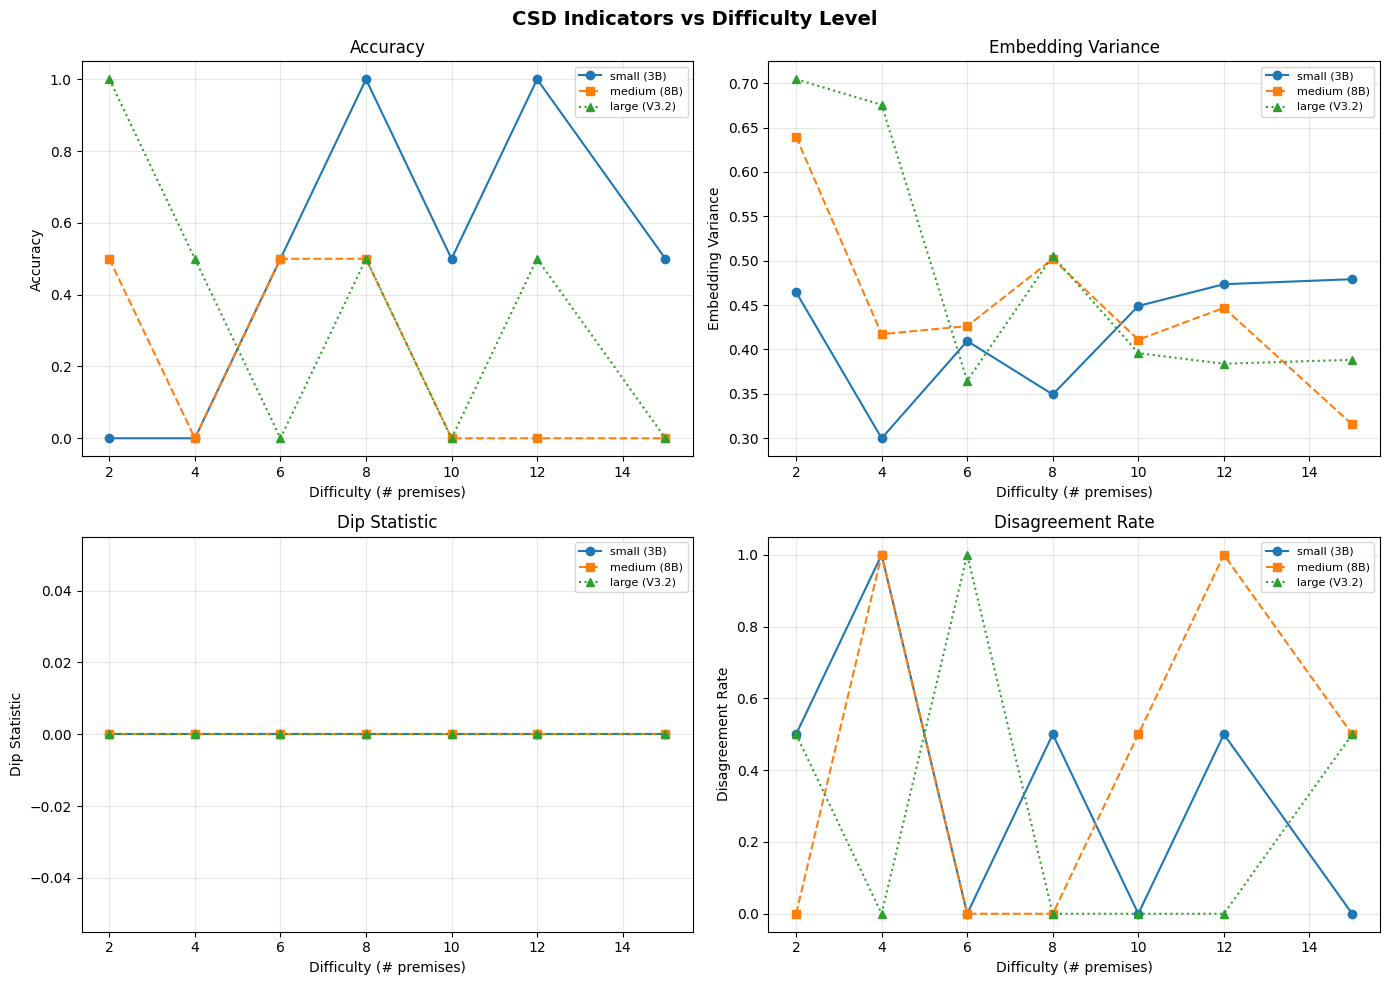

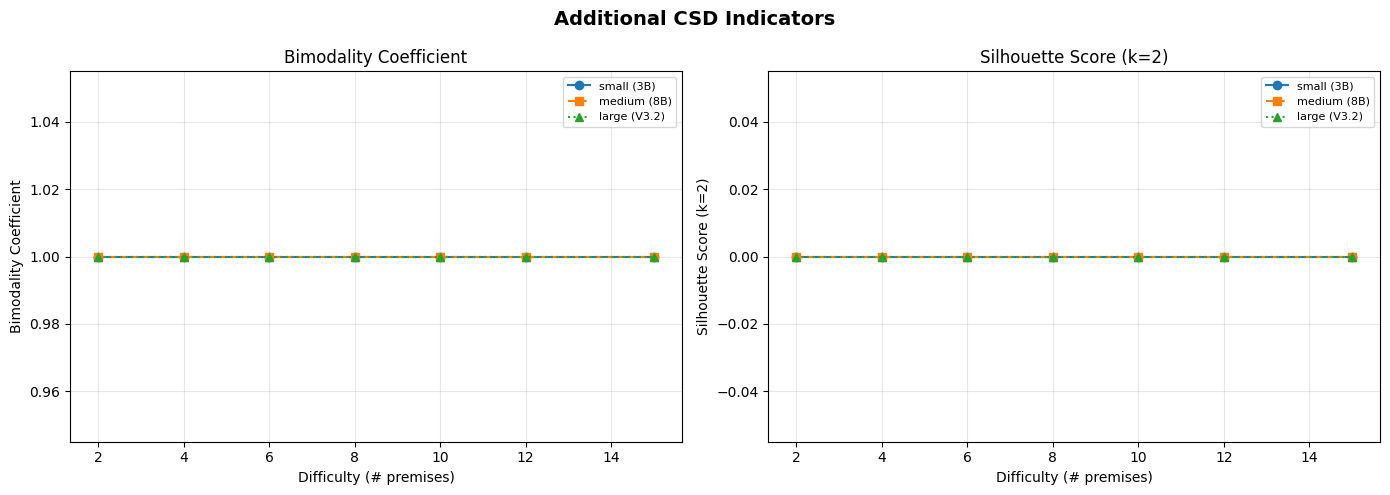

Visualization complete.


In [12]:
# ── CSD Indicators vs Difficulty ─────────────────────────────────────────────
indicators = [
    ("accuracy", "Accuracy", "tab:blue"),
    ("embedding_variance", "Embedding Variance", "tab:orange"),
    ("dip_statistic", "Dip Statistic", "tab:green"),
    ("disagreement_rate", "Disagreement Rate", "tab:red"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

model_styles = {
    "mistralai/ministral-3b-2512": ("o-", "small (3B)"),
    "mistralai/ministral-8b-2512": ("s--", "medium (8B)"),
    "deepseek/deepseek-v3.2": ("^:", "large (V3.2)"),
}

for ax, (indicator_key, indicator_name, _) in zip(axes, indicators):
    for model_id, (style, label) in model_styles.items():
        ds = sorted(csd_by_model.get(model_id, {}).keys())
        vals = [csd_by_model[model_id][d].get(indicator_key, 0) for d in ds]
        if ds and vals:
            ax.plot(ds, vals, style, label=label, markersize=6, linewidth=1.5)

    ax.set_xlabel("Difficulty (# premises)")
    ax.set_ylabel(indicator_name)
    ax.set_title(indicator_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("CSD Indicators vs Difficulty Level", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Bimodality & Silhouette ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (indicator_key, indicator_name) in zip(axes, [
    ("bimodality_coefficient", "Bimodality Coefficient"),
    ("silhouette_k2", "Silhouette Score (k=2)"),
]):
    for model_id, (style, label) in model_styles.items():
        ds = sorted(csd_by_model.get(model_id, {}).keys())
        vals = [csd_by_model[model_id][d].get(indicator_key, 0) for d in ds]
        if ds and vals:
            ax.plot(ds, vals, style, label=label, markersize=6, linewidth=1.5)

    ax.set_xlabel("Difficulty (# premises)")
    ax.set_ylabel(indicator_name)
    ax.set_title(indicator_name)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Additional CSD Indicators", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Visualization complete.")